In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20,t_ramp=5):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_edge=int(t_ramp*2/dt) #Määritellään reunojen pituudeksi 2x rampin pituus, jotta amplitudi menee lähemmäs nollaa
    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge],time_unit=dt,drag=True)
    U_floquet=evolution.U_floquet(A*pulse.raw[N_edge:N_edge+K],dt)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*pulse.raw[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/K)+1

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,K*k,N_edge],time_unit=dt,drag=True)
        for i in range(0, N_edge): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*pulse.raw[N_edge+K*k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        sim_vals = sim_pulse(f_d+i/scale,A,evolution,dim,f_rabi)
        AC_stark_vals.append(i/scale)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=f_d-f_q (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

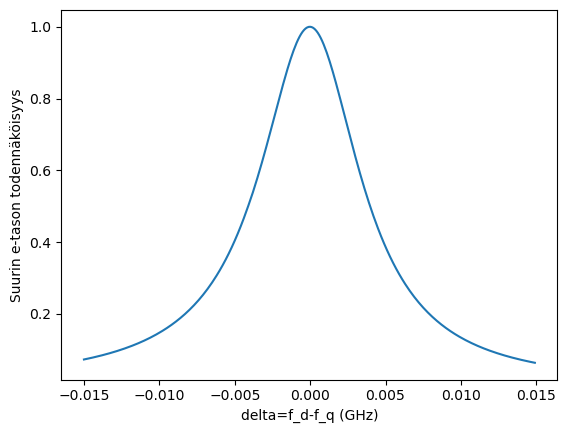

Amplitudi (GHz): 0.00405663690363797
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999720352242344
Pulssin pituus (ns): 771.3350633302528
Rabi-taajuus (fourier):  0.0006455692586171219


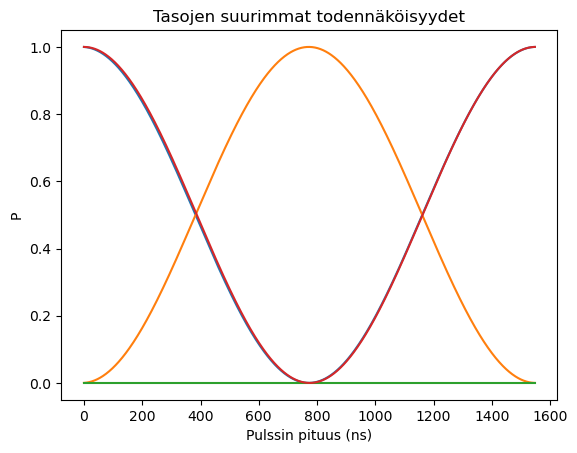

---------------------------------------------


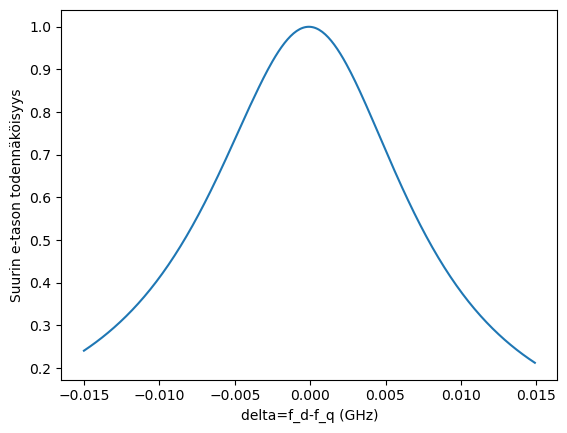

Amplitudi (GHz): 0.00811327380727594
AC-stark siirtymä (GHz): -0.0001
E-tason suurin todennäköisyys: 0.9999966534217061
Pulssin pituus (ns): 382.57923143298564
Rabi-taajuus (fourier):  0.001291235800097349


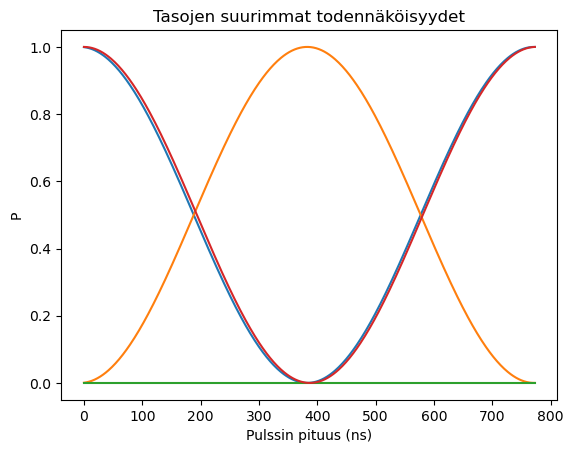

---------------------------------------------


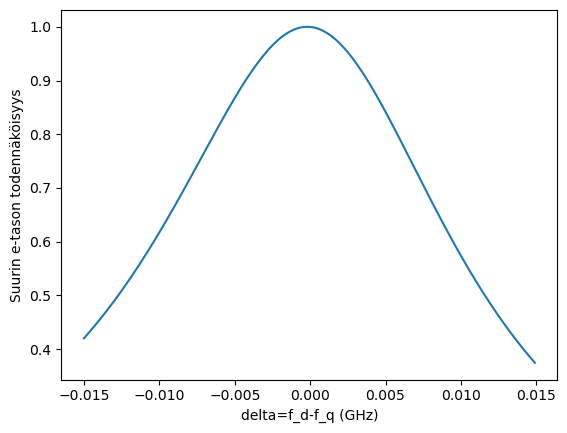

Amplitudi (GHz): 0.01216991071091391
AC-stark siirtymä (GHz): -0.0002
E-tason suurin todennäköisyys: 0.9999992837071215
Pulssin pituus (ns): 252.47753863785405
Rabi-taajuus (fourier):  0.0019364186699291099


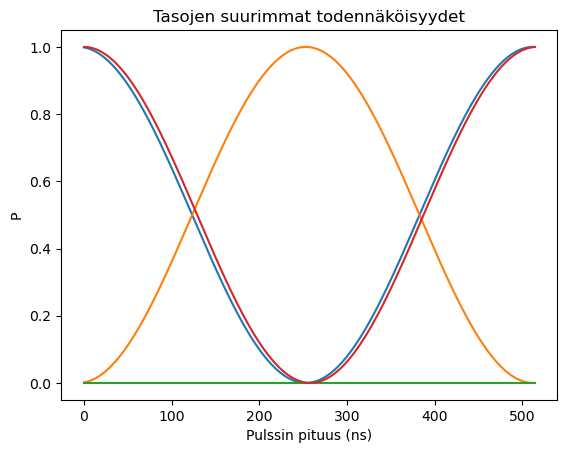

---------------------------------------------


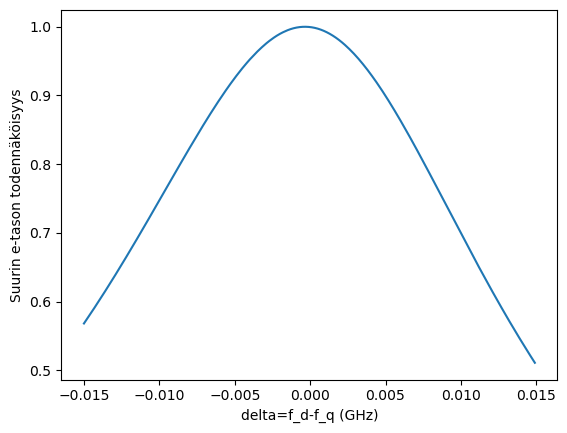

Amplitudi (GHz): 0.01622654761455188
AC-stark siirtymä (GHz): -0.0003
E-tason suurin todennäköisyys: 0.9999861178170842
Pulssin pituus (ns): 187.42659700846784
Rabi-taajuus (fourier):  0.0025823442762402246


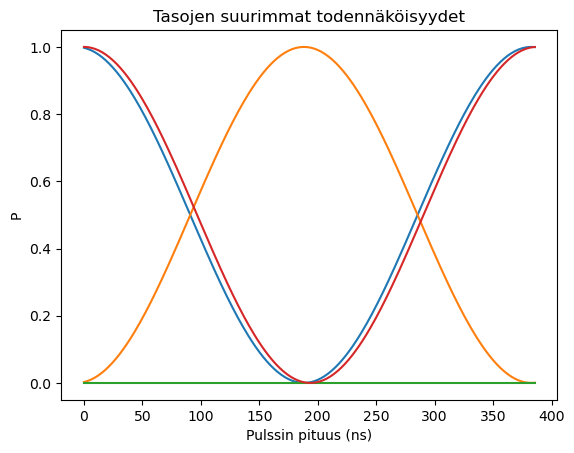

---------------------------------------------


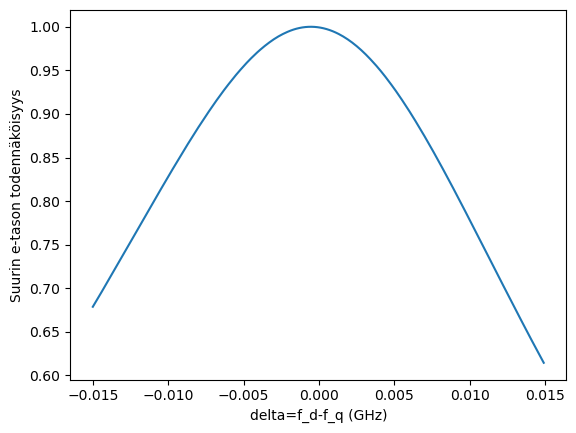

Amplitudi (GHz): 0.02028318451818985
AC-stark siirtymä (GHz): -0.0005
E-tason suurin todennäköisyys: 0.99999452693411
Pulssin pituus (ns): 148.7094256972046
Rabi-taajuus (fourier):  0.003227771190357189


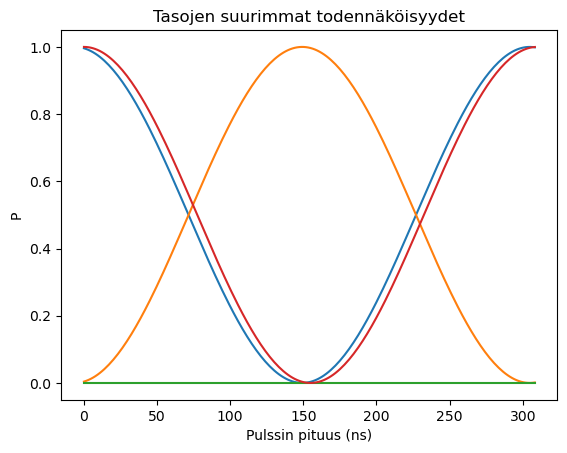

---------------------------------------------


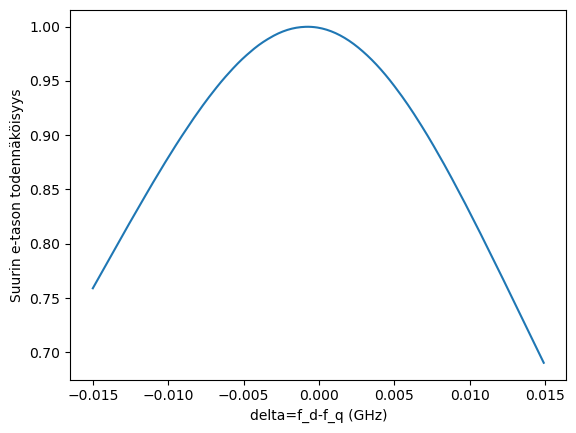

Amplitudi (GHz): 0.02433982142182782
AC-stark siirtymä (GHz): -0.0007
E-tason suurin todennäköisyys: 0.9999880728035937
Pulssin pituus (ns): 123.93063218599653
Rabi-taajuus (fourier):  0.0038723599705028145


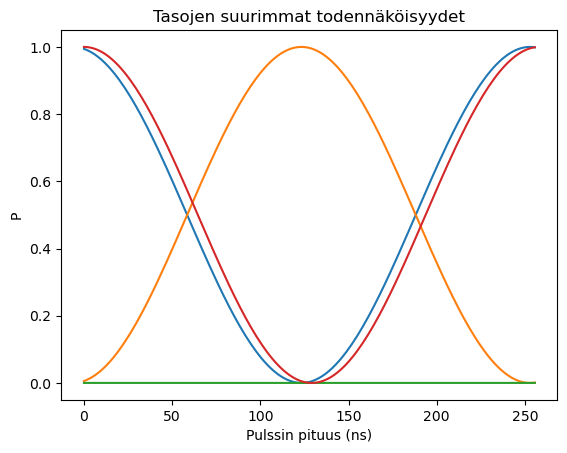

---------------------------------------------


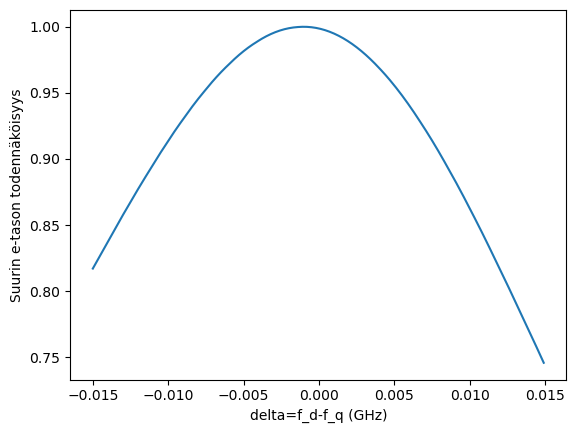

Amplitudi (GHz): 0.02839645832546579
AC-stark siirtymä (GHz): -0.001
E-tason suurin todennäköisyys: 0.9999958506547192
Pulssin pituus (ns): 105.34882955250656
Rabi-taajuus (fourier):  0.00451696753393906


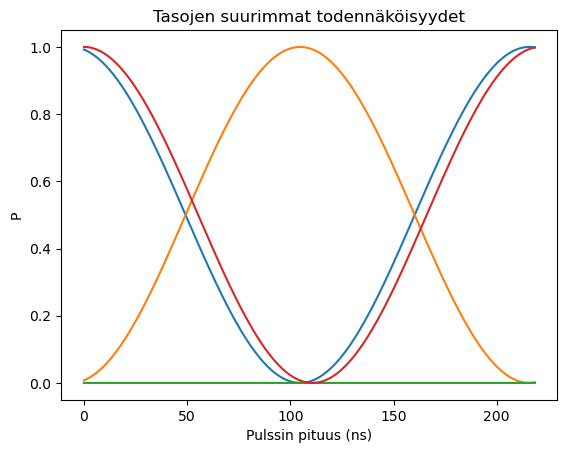

---------------------------------------------


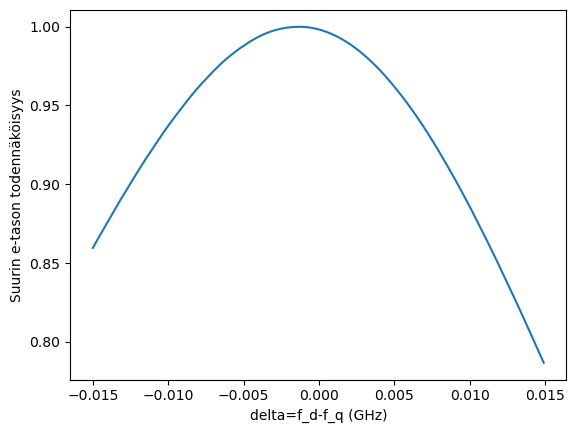

Amplitudi (GHz): 0.03245309522910376
AC-stark siirtymä (GHz): -0.0013
E-tason suurin todennäköisyys: 0.9999899935446352
Pulssin pituus (ns): 91.41236398658769
Rabi-taajuus (fourier):  0.005163415312935713


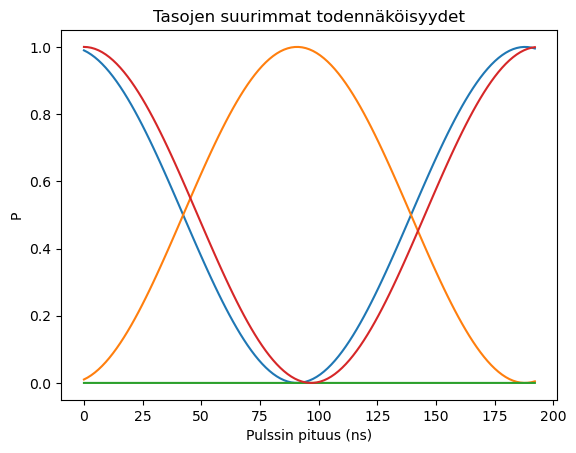

---------------------------------------------


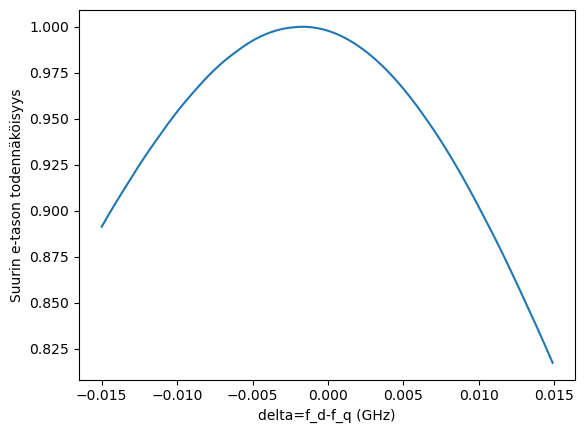

Amplitudi (GHz): 0.03650973213274173
AC-stark siirtymä (GHz): -0.0017
E-tason suurin todennäköisyys: 0.9999916745457664
Pulssin pituus (ns): 80.57477680607307
Rabi-taajuus (fourier):  0.005808850154272975


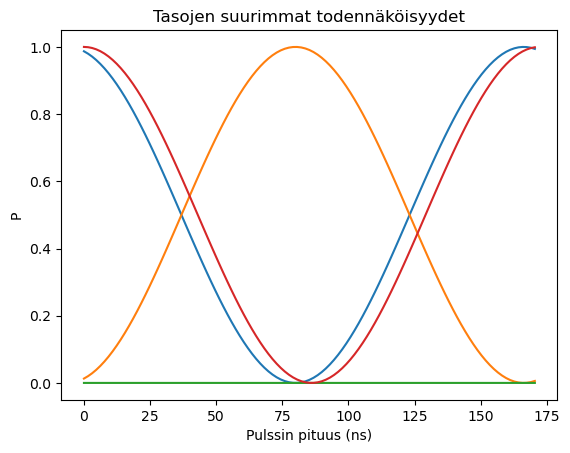

---------------------------------------------


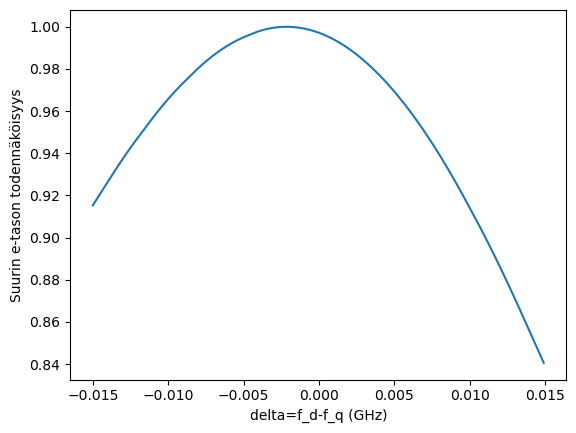

Amplitudi (GHz): 0.04056636903637971
AC-stark siirtymä (GHz): -0.0022
E-tason suurin todennäköisyys: 0.9999951686906069
Pulssin pituus (ns): 71.2864772592522
Rabi-taajuus (fourier):  0.0064528367466818145


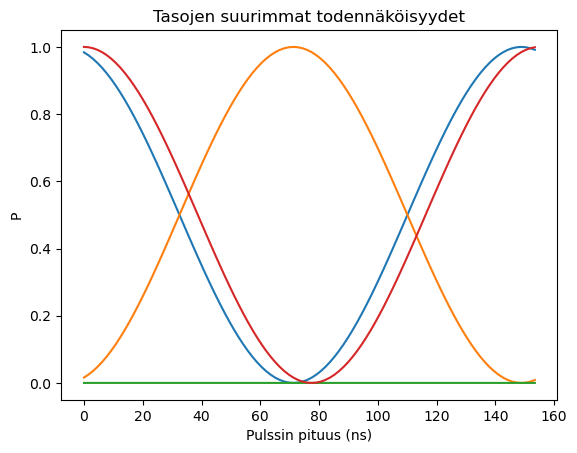

---------------------------------------------


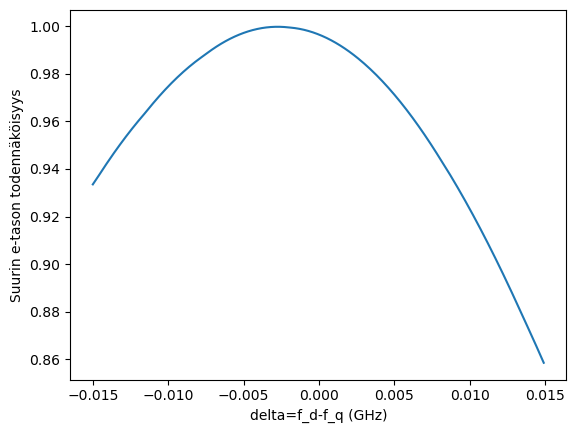

Amplitudi (GHz): 0.04462300594001767
AC-stark siirtymä (GHz): -0.0027
E-tason suurin todennäköisyys: 0.9999889935542644
Pulssin pituus (ns): 63.54578369564296
Rabi-taajuus (fourier):  0.007097954864649456


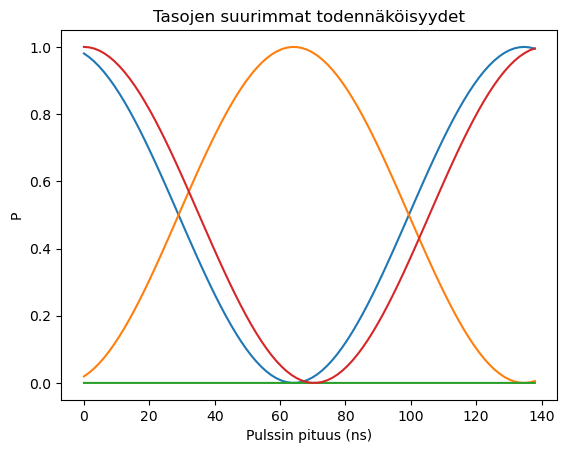

---------------------------------------------


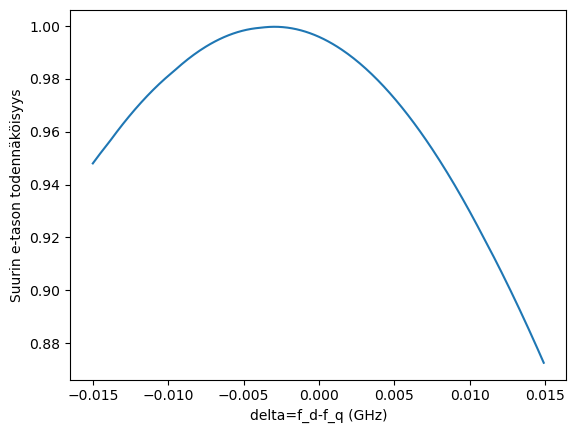

Amplitudi (GHz): 0.04867964284365564
AC-stark siirtymä (GHz): -0.003
E-tason suurin todennäköisyys: 0.9999779766825551
Pulssin pituus (ns): 58.900450965044804
Rabi-taajuus (fourier):  0.007744974198243793


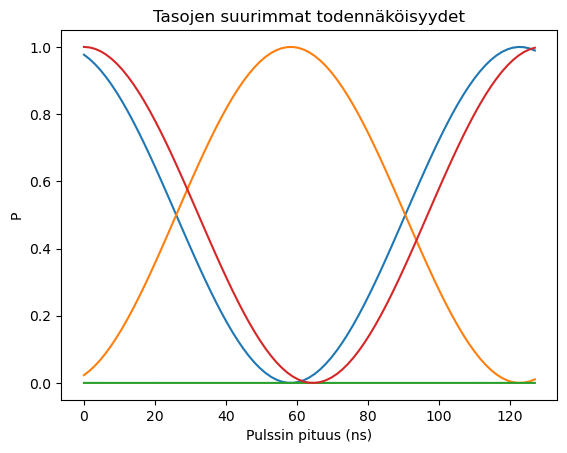

---------------------------------------------


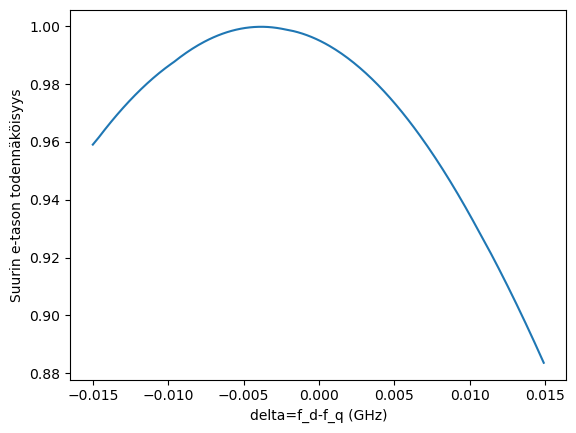

Amplitudi (GHz): 0.05273627974729361
AC-stark siirtymä (GHz): -0.0038
E-tason suurin todennäköisyys: 0.9999825232133642
Pulssin pituus (ns): 52.71080616452777
Rabi-taajuus (fourier):  0.008387893715984843


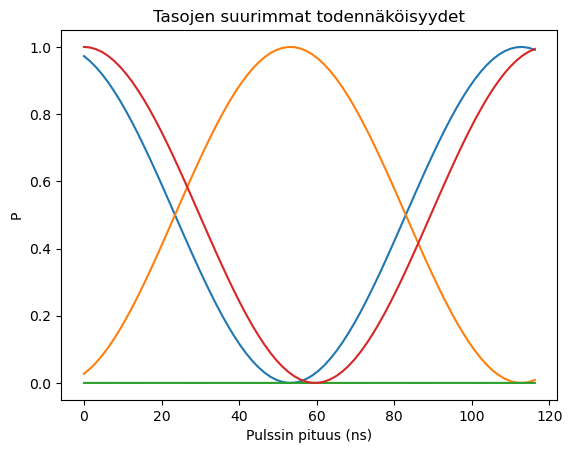

---------------------------------------------


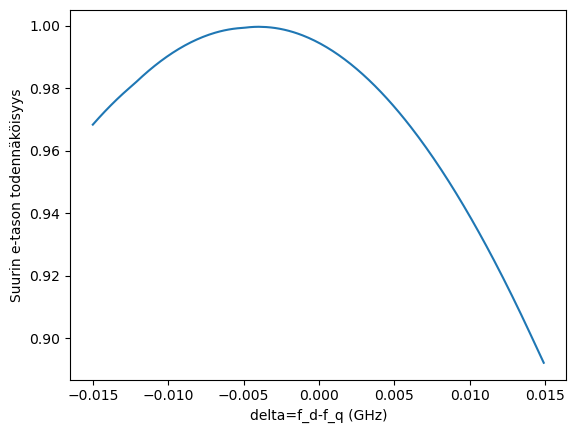

Amplitudi (GHz): 0.056792916650931585
AC-stark siirtymä (GHz): -0.004
E-tason suurin todennäköisyys: 0.9999668590447661
Pulssin pituus (ns): 49.61261879870301
Rabi-taajuus (fourier):  0.009033574170456807


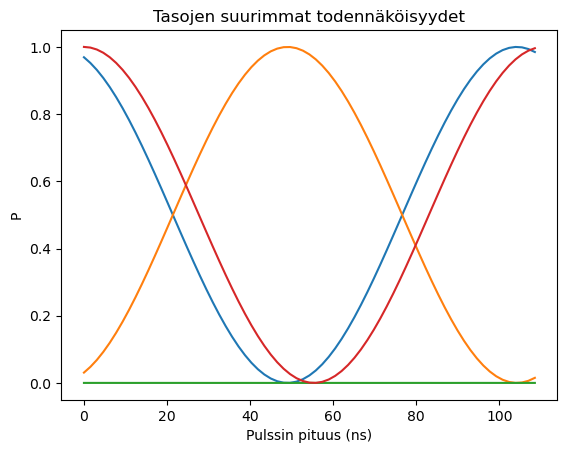

---------------------------------------------


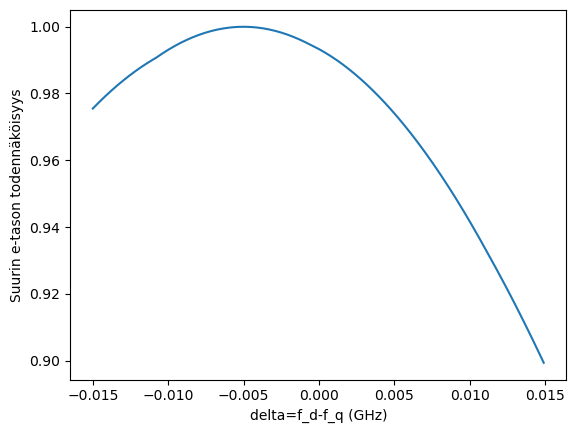

Amplitudi (GHz): 0.060849553554569544
AC-stark siirtymä (GHz): -0.005
E-tason suurin todennäköisyys: 0.9999769260568995
Pulssin pituus (ns): 44.97253289024969
Rabi-taajuus (fourier):  0.00968225286527814


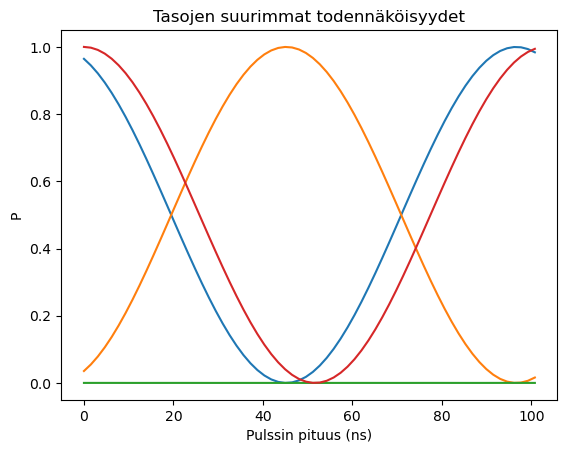

---------------------------------------------


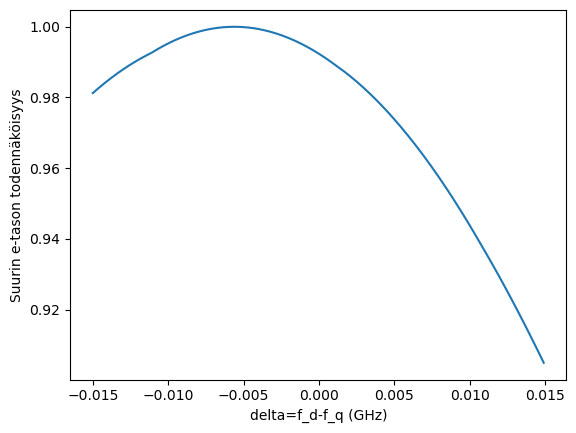

Amplitudi (GHz): 0.06490619045820752
AC-stark siirtymä (GHz): -0.0056
E-tason suurin todennäköisyys: 0.999978060682024
Pulssin pituus (ns): 41.87718041805566
Rabi-taajuus (fourier):  0.010315880765786704


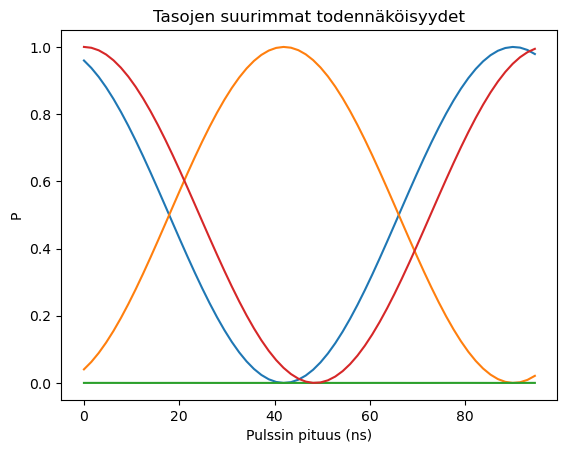

---------------------------------------------


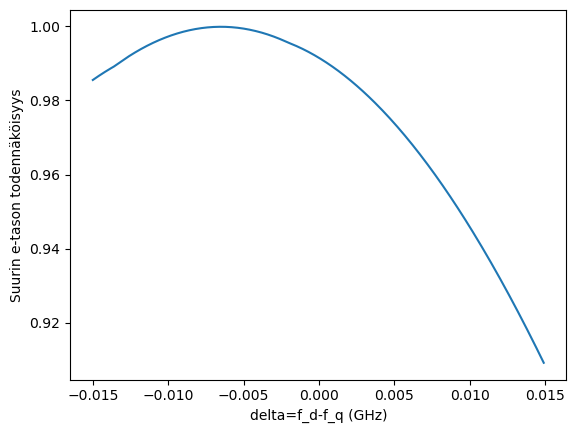

Amplitudi (GHz): 0.06896282736184549
AC-stark siirtymä (GHz): -0.0065
E-tason suurin todennäköisyys: 0.9999541080318267
Pulssin pituus (ns): 38.78378346628121
Rabi-taajuus (fourier):  0.010962573272327997


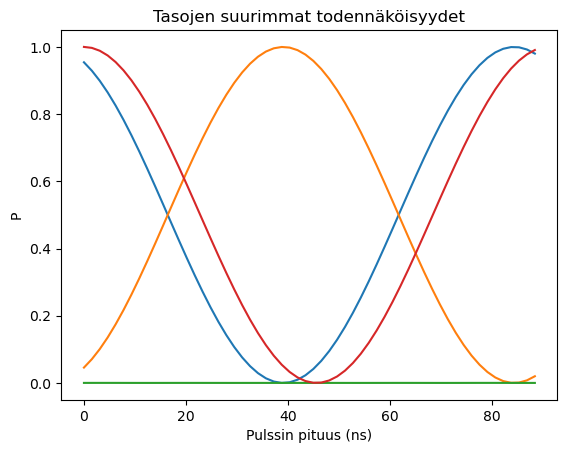

---------------------------------------------


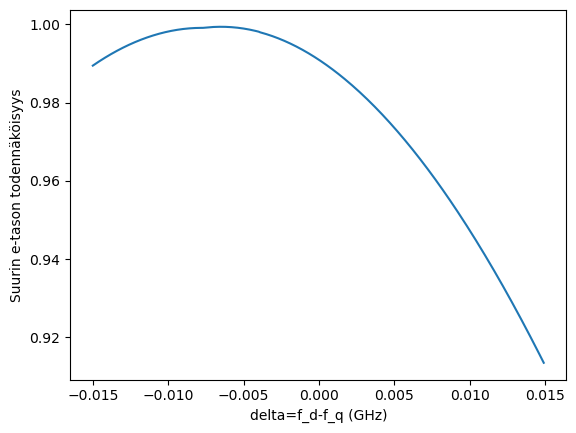

Amplitudi (GHz): 0.07301946426548346
AC-stark siirtymä (GHz): -0.0065
E-tason suurin todennäköisyys: 0.9998912301904089
Pulssin pituus (ns): 37.23243212762996
Rabi-taajuus (fourier):  0.01161440195338534


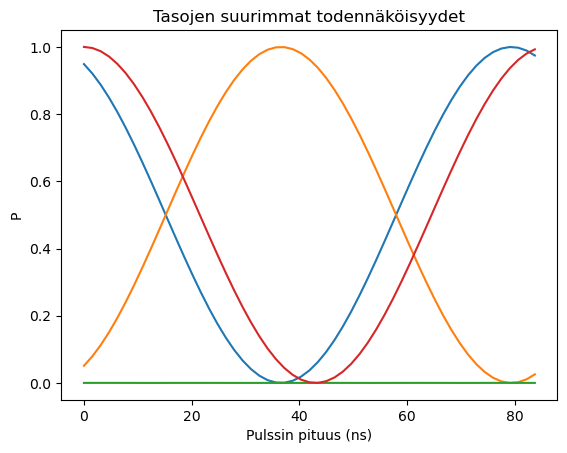

---------------------------------------------


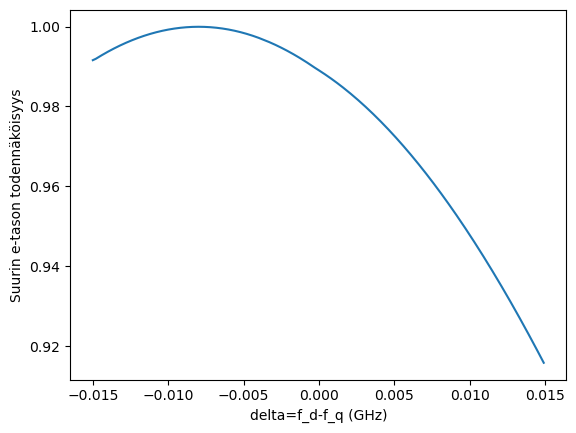

Amplitudi (GHz): 0.07707610116912145
AC-stark siirtymä (GHz): -0.008
E-tason suurin todennäköisyys: 0.9999403308699394
Pulssin pituus (ns): 34.1423743467195
Rabi-taajuus (fourier):  0.012250201064605486


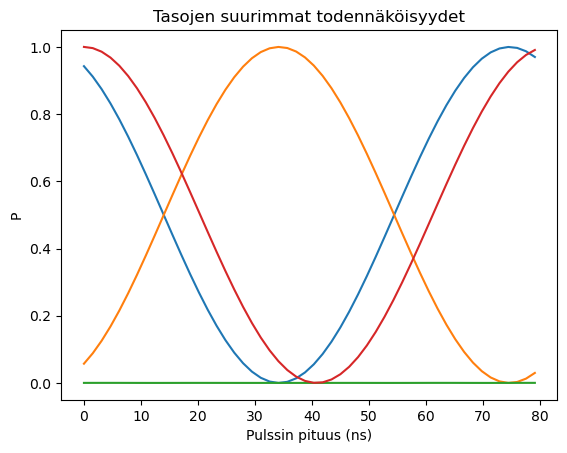

---------------------------------------------


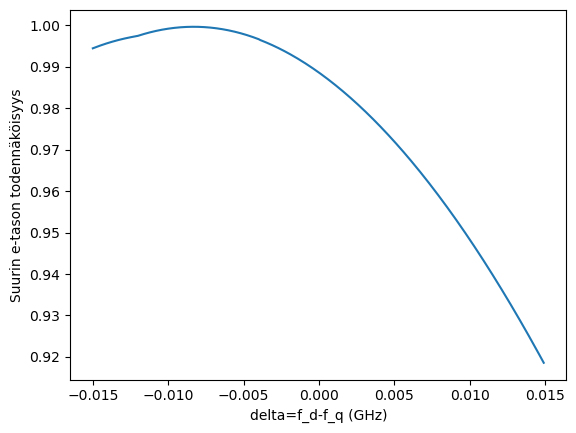

Amplitudi (GHz): 0.0811327380727594
AC-stark siirtymä (GHz): -0.0083
E-tason suurin todennäköisyys: 0.9998993834241809
Pulssin pituus (ns): 32.592863339066334
Rabi-taajuus (fourier):  0.012912080751810037


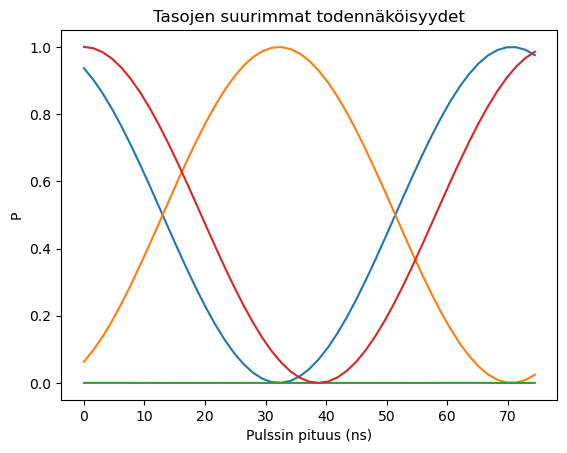

---------------------------------------------


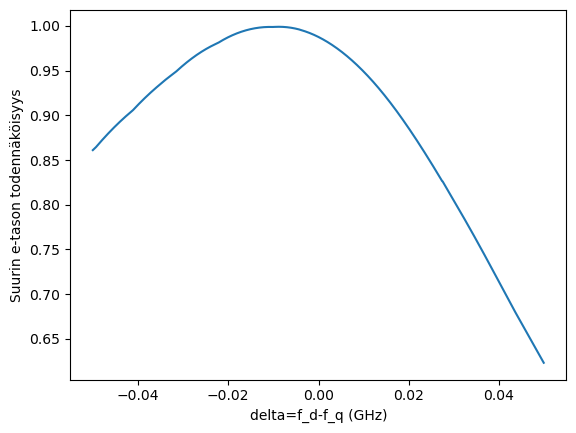

Amplitudi (GHz): 0.08518937497639738
AC-stark siirtymä (GHz): -0.0088
E-tason suurin todennäköisyys: 0.9998289984075789
Pulssin pituus (ns): 31.044656475820997
Rabi-taajuus (fourier):  0.013534312017726365


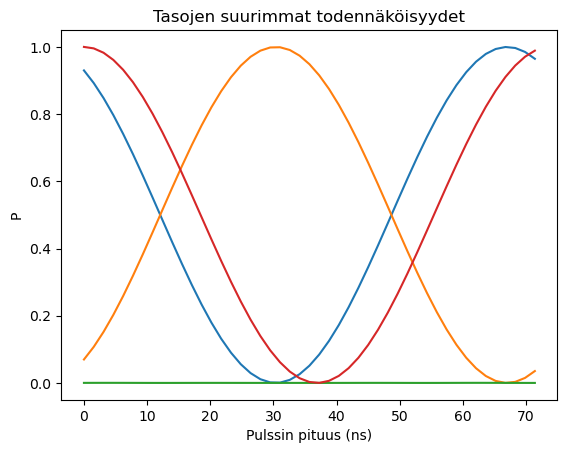

---------------------------------------------


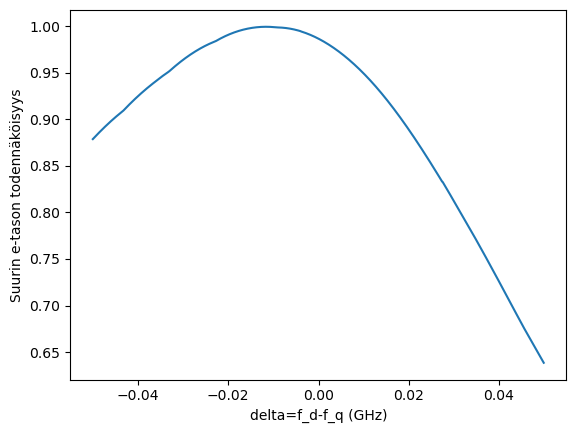

Amplitudi (GHz): 0.08924601188003535
AC-stark siirtymä (GHz): -0.0116
E-tason suurin todennäköisyys: 0.9997957751031855
Pulssin pituus (ns): 27.959531204157024
Rabi-taajuus (fourier):  0.014180344013284532


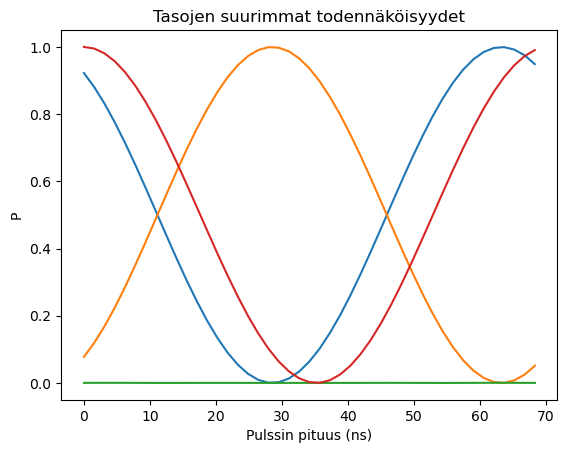

---------------------------------------------


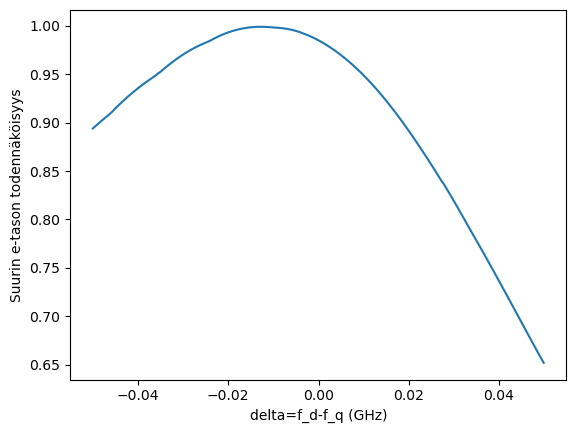

Amplitudi (GHz): 0.09330264878367331
AC-stark siirtymä (GHz): -0.0128
E-tason suurin todennäköisyys: 0.9997223679906465
Pulssin pituus (ns): 26.41405990581851
Rabi-taajuus (fourier):  0.014829415490124592


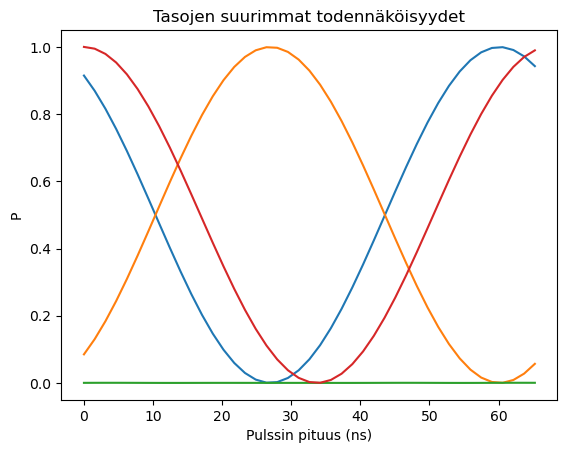

---------------------------------------------


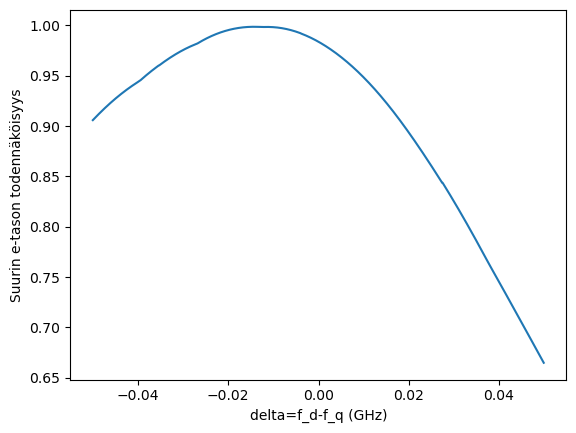

Amplitudi (GHz): 0.09735928568731128
AC-stark siirtymä (GHz): -0.0143
E-tason suurin todennäköisyys: 0.9996522123578732
Pulssin pituus (ns): 24.869516646274295
Rabi-taajuus (fourier):  0.015465334131172343


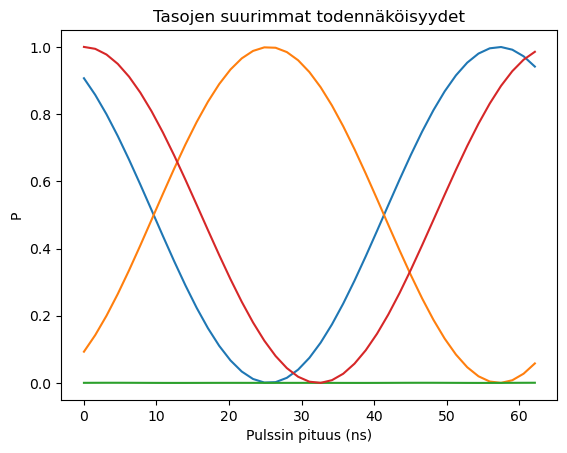

---------------------------------------------


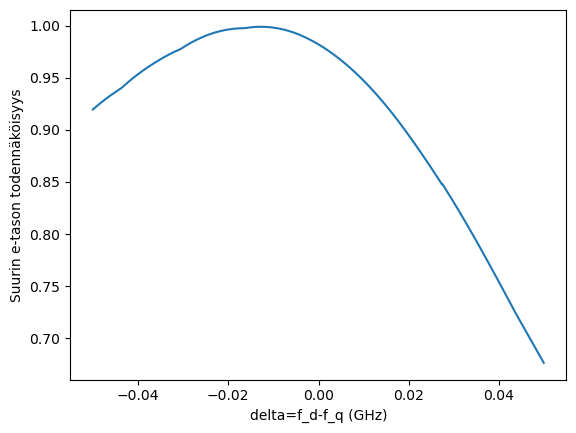

Amplitudi (GHz): 0.10141592259094925
AC-stark siirtymä (GHz): -0.0128
E-tason suurin todennäköisyys: 0.9997391736554863
Pulssin pituus (ns): 24.86029167606448
Rabi-taajuus (fourier):  0.016130241410310962


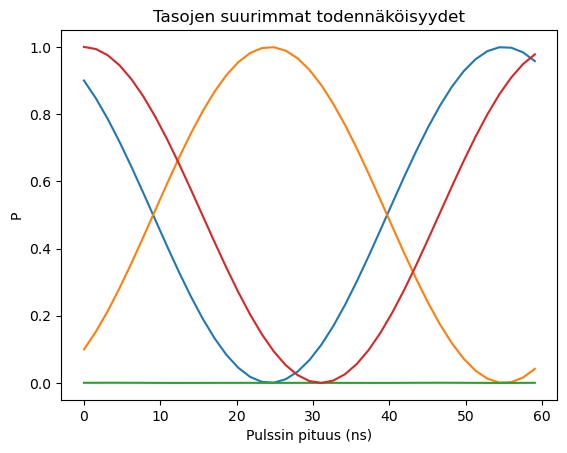

---------------------------------------------


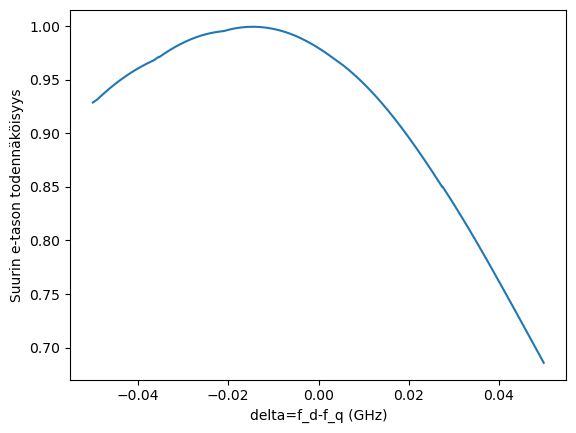

Amplitudi (GHz): 0.10547255949458723
AC-stark siirtymä (GHz): -0.0146
E-tason suurin todennäköisyys: 0.9997054321149815
Pulssin pituus (ns): 23.316902308058495
Rabi-taajuus (fourier):  0.0167528685774438


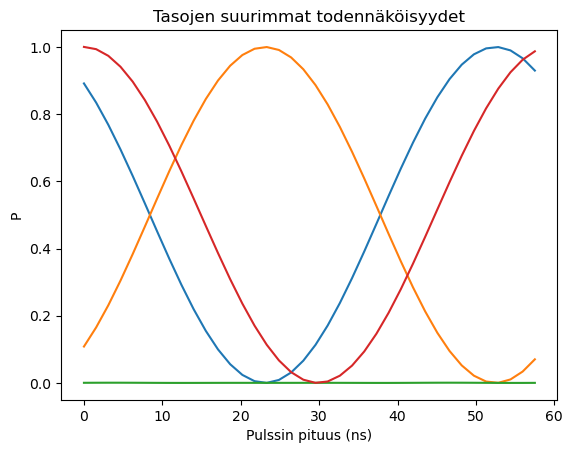

---------------------------------------------


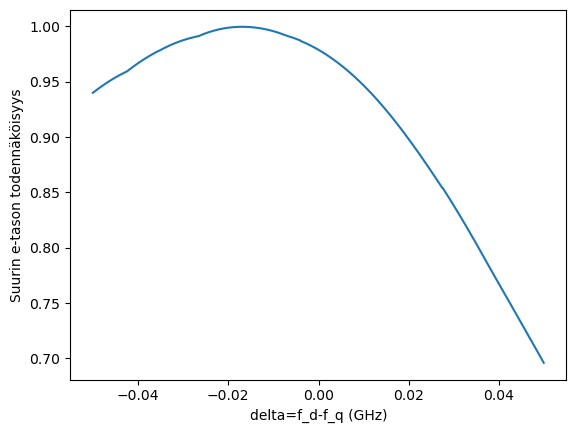

Amplitudi (GHz): 0.1095291963982252
AC-stark siirtymä (GHz): -0.0169
E-tason suurin todennäköisyys: 0.9997830133023056
Pulssin pituus (ns): 21.774832470227956
Rabi-taajuus (fourier):  0.017423959268420885


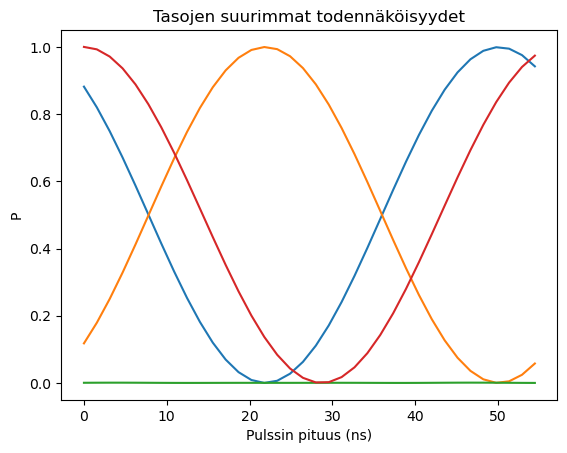

---------------------------------------------


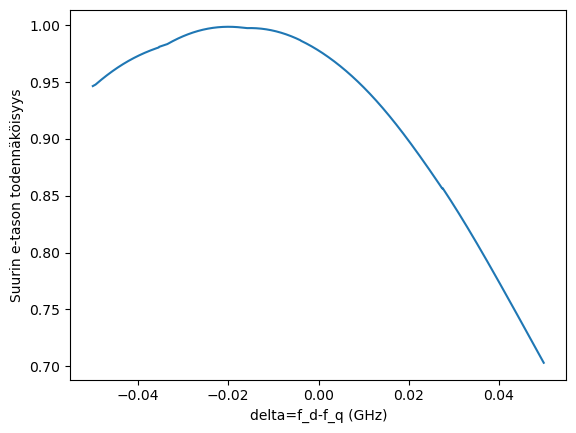

Amplitudi (GHz): 0.11358583330186316
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9994867456635357
Pulssin pituus (ns): 20.235015173081393
Rabi-taajuus (fourier):  0.018046368446099602


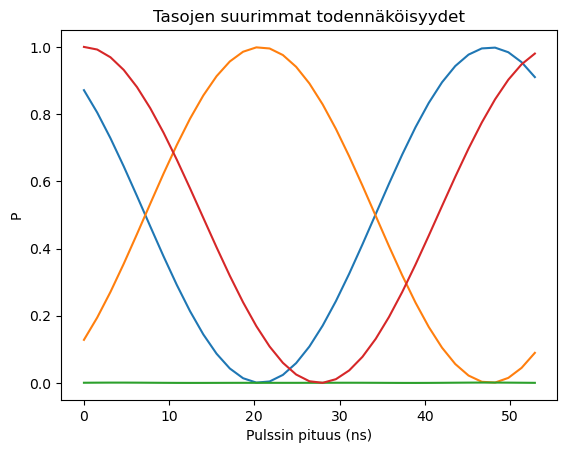

---------------------------------------------


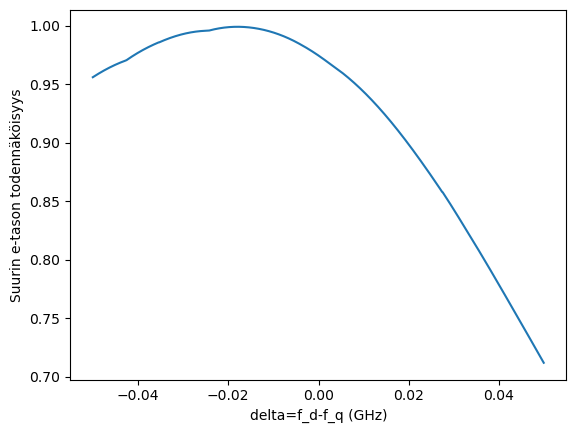

Amplitudi (GHz): 0.11764247020550113
AC-stark siirtymä (GHz): -0.018
E-tason suurin todennäköisyys: 0.9995805654750461
Pulssin pituus (ns): 20.224994457847075
Rabi-taajuus (fourier):  0.0186851461211433


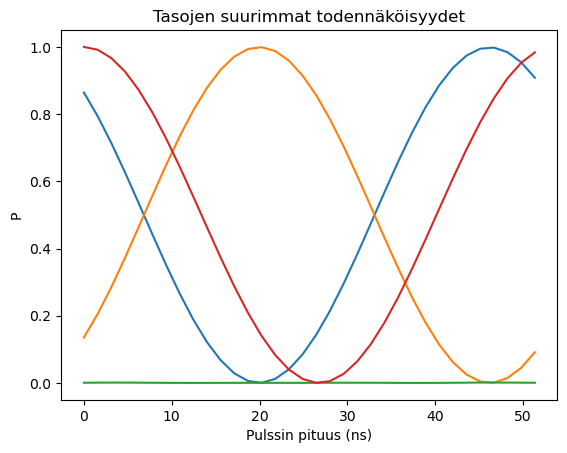

---------------------------------------------


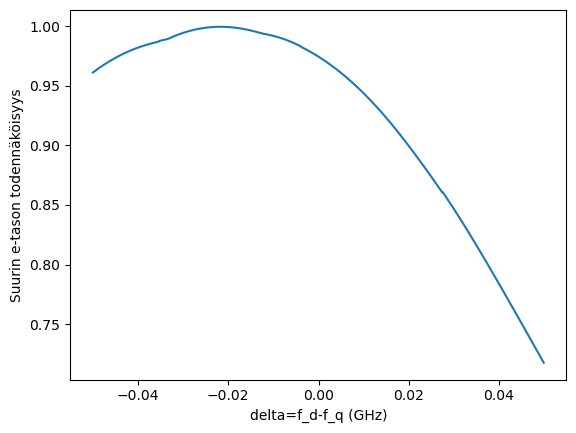

Amplitudi (GHz): 0.1216991071091391
AC-stark siirtymä (GHz): -0.0217
E-tason suurin todennäköisyys: 0.9995581980862566
Pulssin pituus (ns): 18.68634516147568
Rabi-taajuus (fourier):  0.01934277570114125


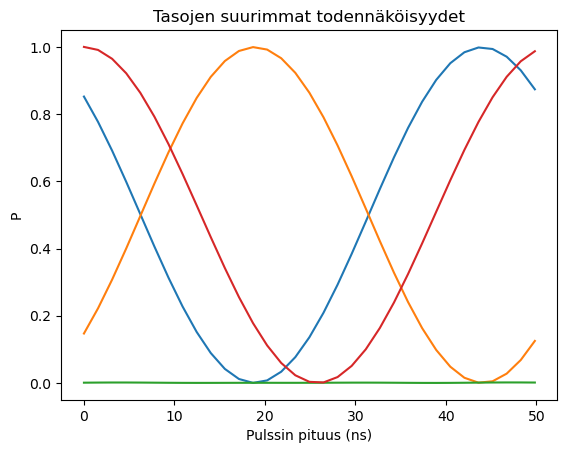

---------------------------------------------


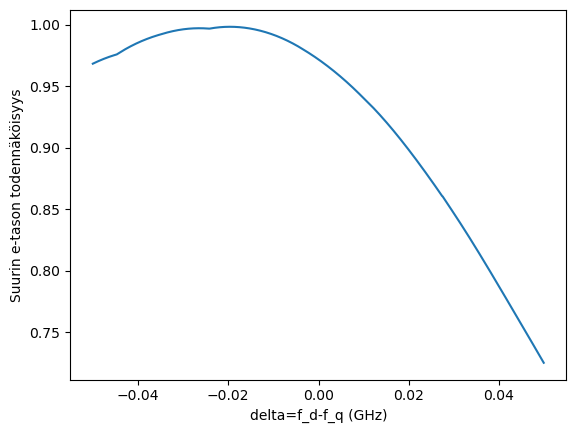

Amplitudi (GHz): 0.12575574401277706
AC-stark siirtymä (GHz): -0.0196
E-tason suurin todennäköisyys: 0.9991674076638505
Pulssin pituus (ns): 18.67662483298333
Rabi-taajuus (fourier):  0.019953862691254116


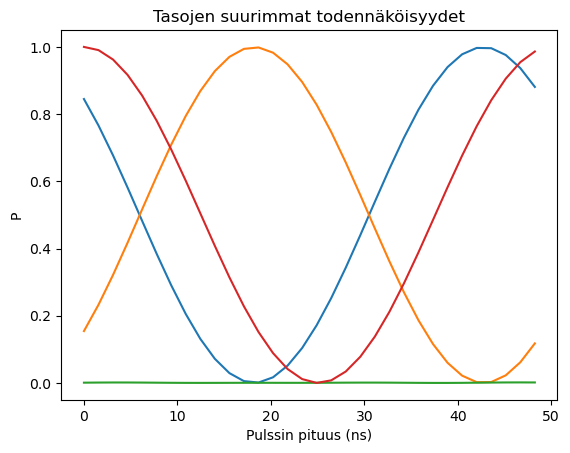

---------------------------------------------


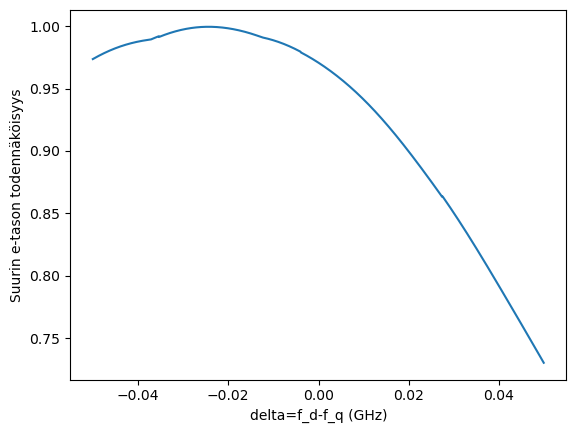

Amplitudi (GHz): 0.12981238091641503
AC-stark siirtymä (GHz): -0.0244
E-tason suurin todennäköisyys: 0.9995313457372493
Pulssin pituus (ns): 17.140619470204836
Rabi-taajuus (fourier):  0.020635062216448275


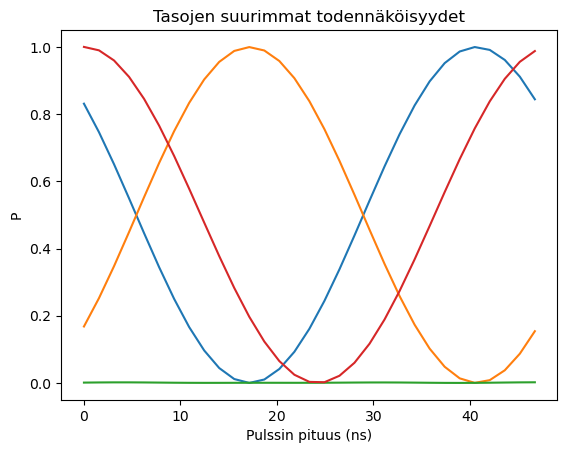

---------------------------------------------


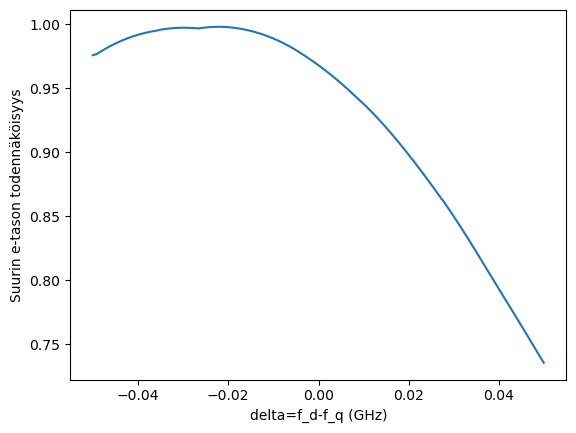

Amplitudi (GHz): 0.133869017820053
AC-stark siirtymä (GHz): -0.0222
E-tason suurin todennäköisyys: 0.9983932592971149
Pulssin pituus (ns): 17.131272598823493
Rabi-taajuus (fourier):  0.021261608470408727


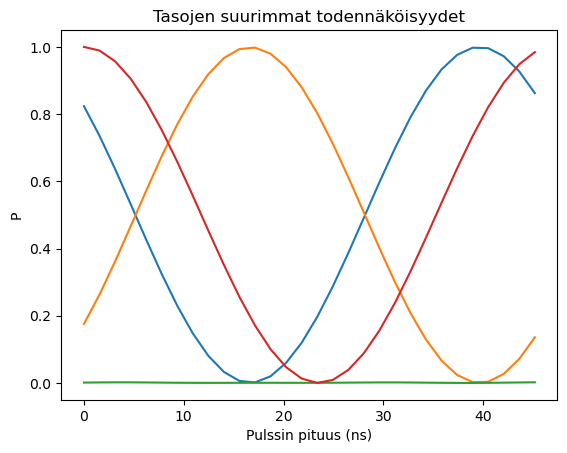

---------------------------------------------


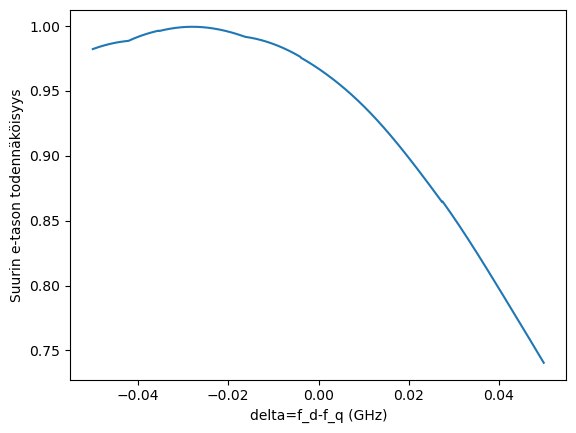

Amplitudi (GHz): 0.13792565472369098
AC-stark siirtymä (GHz): -0.0279
E-tason suurin todennäköisyys: 0.9994431945147333
Pulssin pituus (ns): 15.59591866499358
Rabi-taajuus (fourier):  0.021883733536884636


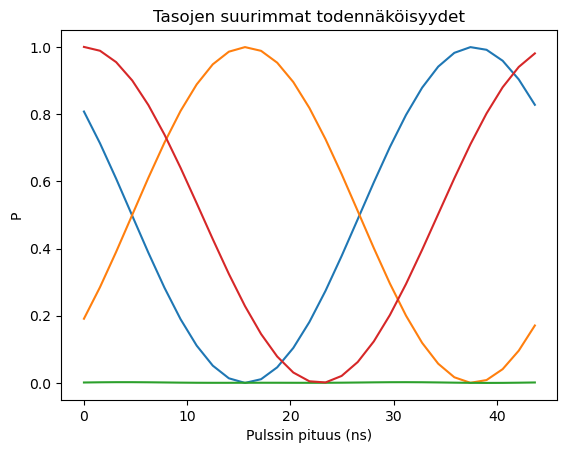

---------------------------------------------


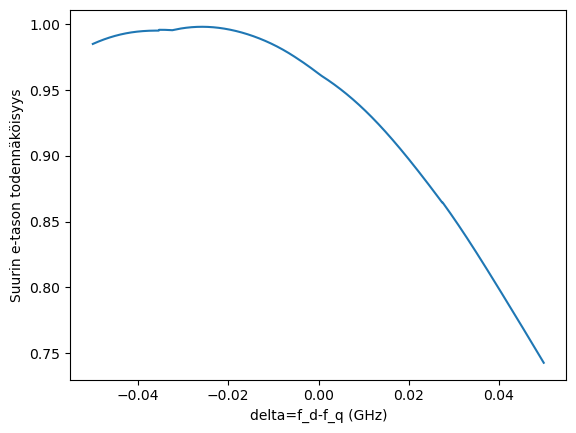

Amplitudi (GHz): 0.14198229162732895
AC-stark siirtymä (GHz): -0.0258
E-tason suurin todennäköisyys: 0.9990181463076468
Pulssin pituus (ns): 15.587793446836795
Rabi-taajuus (fourier):  0.02258900063419763


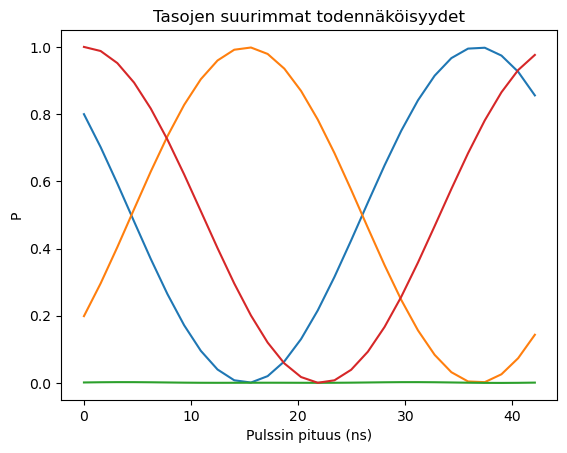

---------------------------------------------


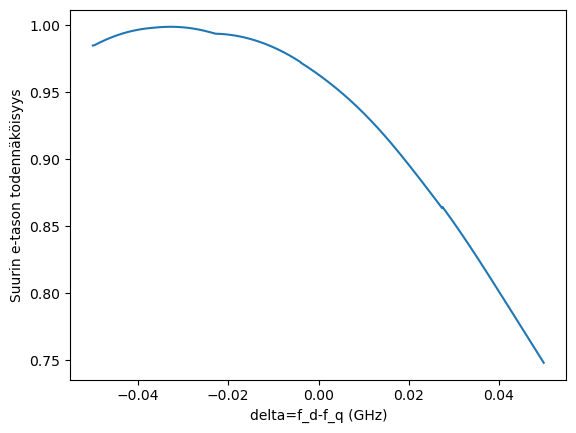

Amplitudi (GHz): 0.14603892853096692
AC-stark siirtymä (GHz): -0.0328
E-tason suurin todennäköisyys: 0.998875482858803
Pulssin pituus (ns): 14.053419439910787
Rabi-taajuus (fourier):  0.023203388891651064


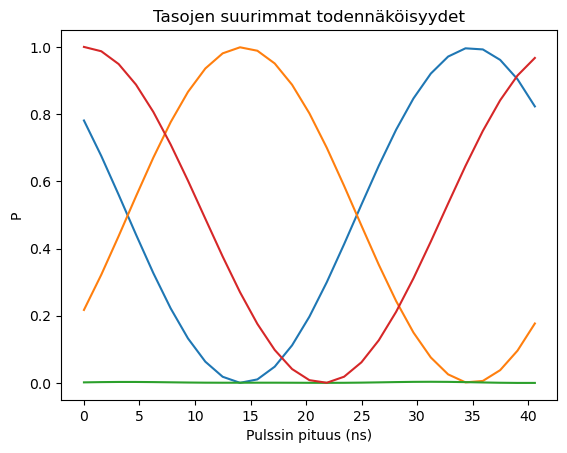

---------------------------------------------


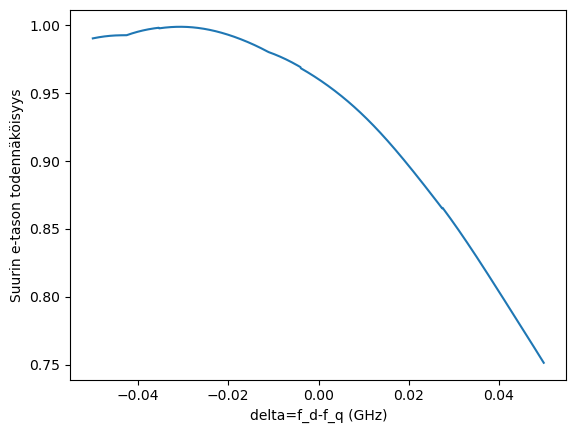

Amplitudi (GHz): 0.1500955654346049
AC-stark siirtymä (GHz): -0.0306
E-tason suurin todennäköisyys: 0.9988323770336666
Pulssin pituus (ns): 14.045740046127818
Rabi-taajuus (fourier):  0.023820210939939464


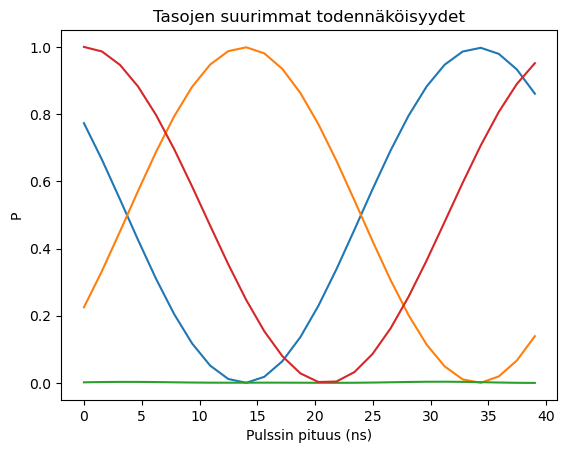

---------------------------------------------


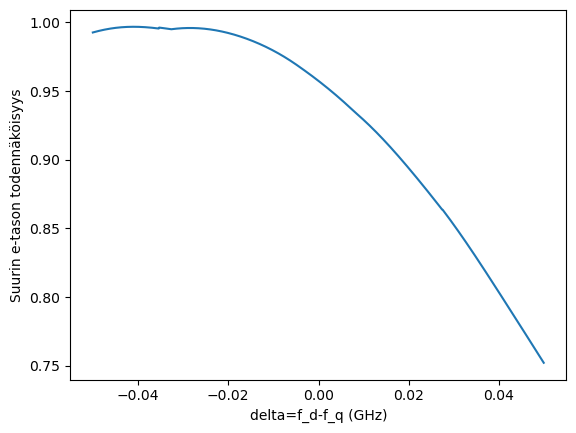

Amplitudi (GHz): 0.15415220233824287
AC-stark siirtymä (GHz): -0.041
E-tason suurin todennäköisyys: 0.9973980163148081
Pulssin pituus (ns): 12.517437124830344
Rabi-taajuus (fourier):  0.026935605715089555


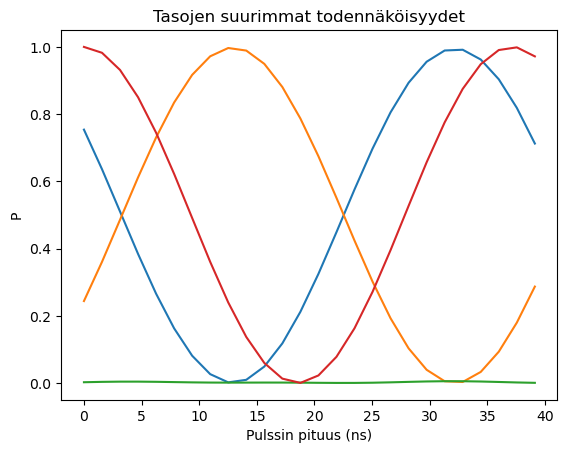

---------------------------------------------


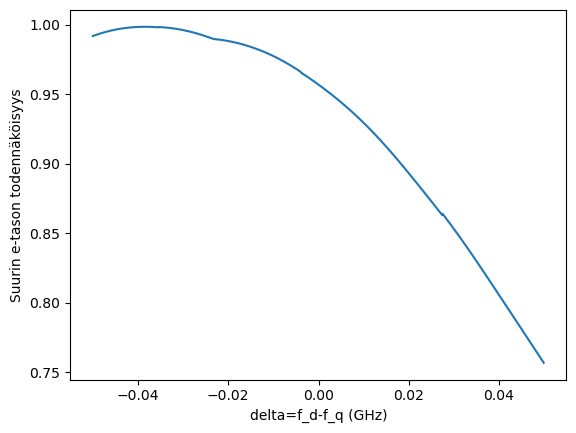

Amplitudi (GHz): 0.15820883924188084
AC-stark siirtymä (GHz): -0.0385
E-tason suurin todennäköisyys: 0.9985820990551206
Pulssin pituus (ns): 12.509649039565318
Rabi-taajuus (fourier):  0.02517741536354117


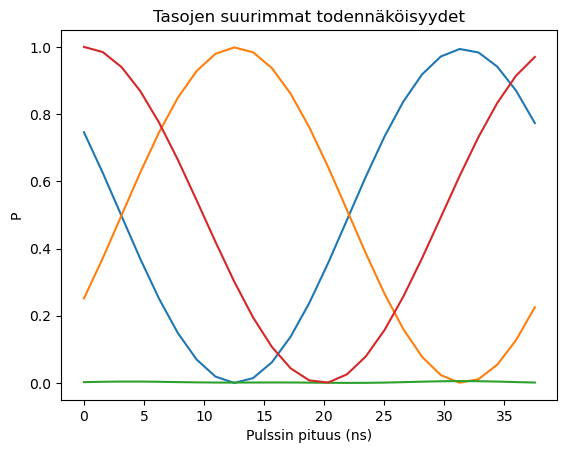

---------------------------------------------


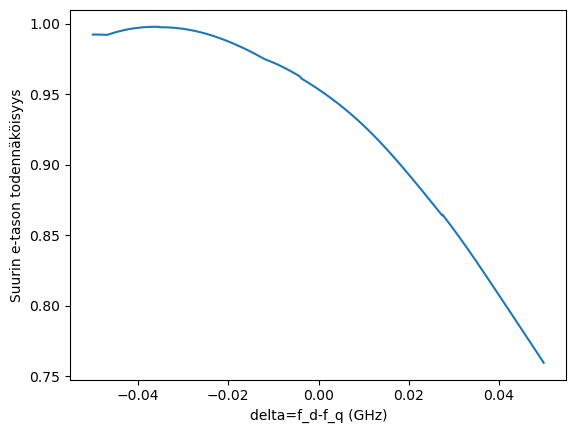

Amplitudi (GHz): 0.1622654761455188
AC-stark siirtymä (GHz): -0.036
E-tason suurin todennäköisyys: 0.9981846137978622
Pulssin pituus (ns): 12.501870639439051
Rabi-taajuus (fourier):  0.025802590225470788


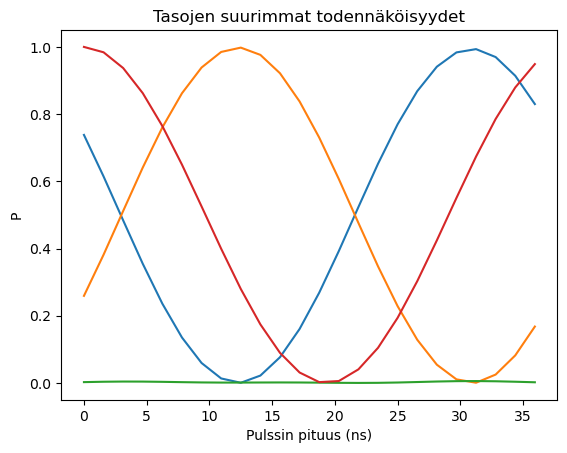

---------------------------------------------


In [6]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.001
max_range = 0.040
N_data=40
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    if i < 20:
        params=find_params(qubit, A, evolution_eigenbasis,A, [-150,150],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,A, [-500,500],10000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,A/m)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 2*np.pi/(f_d_opt)
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.00405663690363797), np.float64(0.00811327380727594), np.float64(0.01216991071091391), np.float64(0.01622654761455188), np.float64(0.02028318451818985), np.float64(0.02433982142182782), np.float64(0.02839645832546579), np.float64(0.03245309522910376), np.float64(0.03650973213274173), np.float64(0.04056636903637971), np.float64(0.04462300594001767), np.float64(0.04867964284365564), np.float64(0.05273627974729361), np.float64(0.056792916650931585), np.float64(0.060849553554569544), np.float64(0.06490619045820752), np.float64(0.06896282736184549), np.float64(0.07301946426548346), np.float64(0.07707610116912145), np.float64(0.0811327380727594), np.float64(0.08518937497639738), np.float64(0.08924601188003535), np.float64(0.09330264878367331), np.float64(0.09735928568731128), np.float64(0.10141592259094925), np.float64(0.10547255949458723), np.float64(0.1095291963982252), np.float64(0.11358583330186316), np.float64(0.11764247020550113), np.float64(0.1216991071091391), np.float64

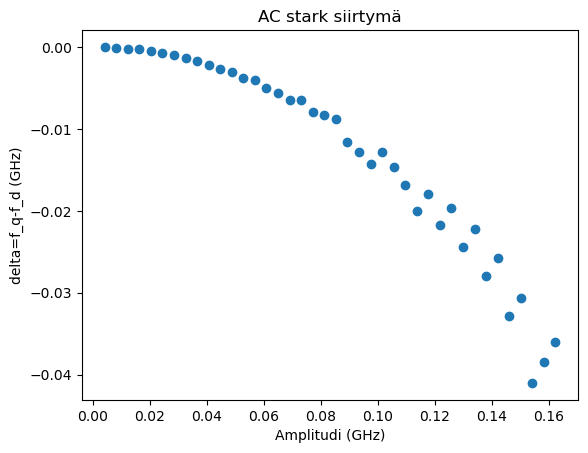

[0.0, -0.0001, -0.0002, -0.0003, -0.0005, -0.0007, -0.001, -0.0013, -0.0017, -0.0022, -0.0027, -0.003, -0.0038, -0.004, -0.005, -0.0056, -0.0065, -0.0065, -0.008, -0.0083, -0.0088, -0.0116, -0.0128, -0.0143, -0.0128, -0.0146, -0.0169, -0.02, -0.018, -0.0217, -0.0196, -0.0244, -0.0222, -0.0279, -0.0258, -0.0328, -0.0306, -0.041, -0.0385, -0.036]


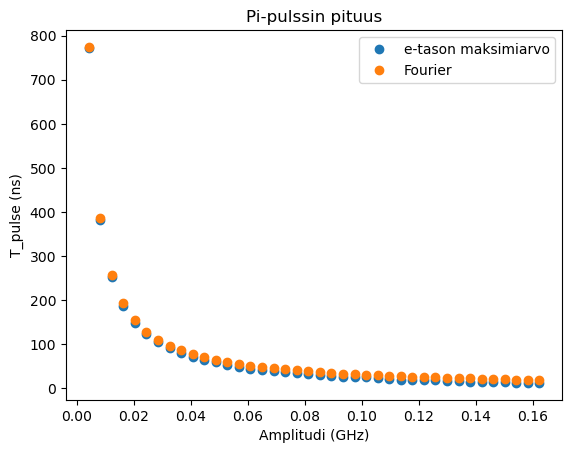

[np.float64(771.3350633302528), np.float64(382.57923143298564), np.float64(252.47753863785405), np.float64(187.42659700846784), np.float64(148.7094256972046), np.float64(123.93063218599653), np.float64(105.34882955250656), np.float64(91.41236398658769), np.float64(80.57477680607307), np.float64(71.2864772592522), np.float64(63.54578369564296), np.float64(58.900450965044804), np.float64(52.71080616452777), np.float64(49.61261879870301), np.float64(44.97253289024969), np.float64(41.87718041805566), np.float64(38.78378346628121), np.float64(37.23243212762996), np.float64(34.1423743467195), np.float64(32.592863339066334), np.float64(31.044656475820997), np.float64(27.959531204157024), np.float64(26.41405990581851), np.float64(24.869516646274295), np.float64(24.86029167606448), np.float64(23.316902308058495), np.float64(21.774832470227956), np.float64(20.235015173081393), np.float64(20.224994457847075), np.float64(18.68634516147568), np.float64(18.67662483298333), np.float64(17.140619470204

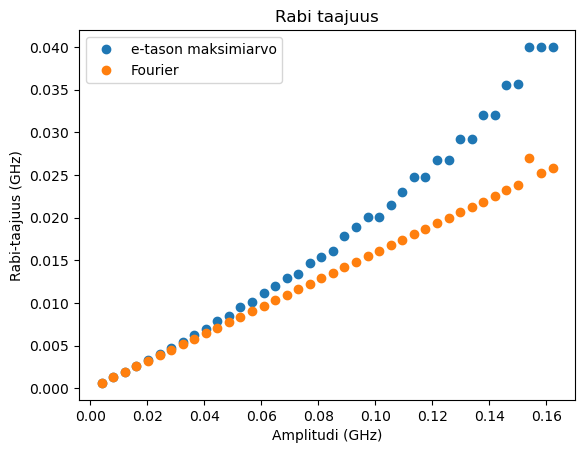

[np.float64(0.0006455692586171219), np.float64(0.001291235800097349), np.float64(0.0019364186699291099), np.float64(0.0025823442762402246), np.float64(0.003227771190357189), np.float64(0.0038723599705028145), np.float64(0.00451696753393906), np.float64(0.005163415312935713), np.float64(0.005808850154272975), np.float64(0.0064528367466818145), np.float64(0.007097954864649456), np.float64(0.007744974198243793), np.float64(0.008387893715984843), np.float64(0.009033574170456807), np.float64(0.00968225286527814), np.float64(0.010315880765786704), np.float64(0.010962573272327997), np.float64(0.01161440195338534), np.float64(0.012250201064605486), np.float64(0.012912080751810037), np.float64(0.013534312017726365), np.float64(0.014180344013284532), np.float64(0.014829415490124592), np.float64(0.015465334131172343), np.float64(0.016130241410310962), np.float64(0.0167528685774438), np.float64(0.017423959268420885), np.float64(0.018046368446099602), np.float64(0.0186851461211433), np.float64(0.01

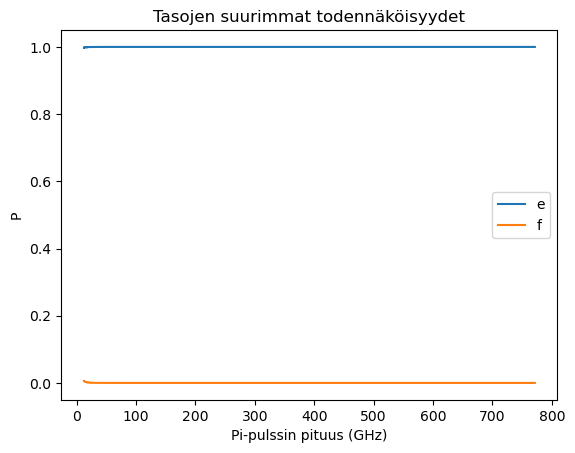

[np.float64(0.9999720352242344), np.float64(0.9999966534217061), np.float64(0.9999992837071215), np.float64(0.9999861178170842), np.float64(0.99999452693411), np.float64(0.9999880728035937), np.float64(0.9999958506547192), np.float64(0.9999899935446352), np.float64(0.9999916745457664), np.float64(0.9999951686906069), np.float64(0.9999889935542644), np.float64(0.9999779766825551), np.float64(0.9999825232133642), np.float64(0.9999668590447661), np.float64(0.9999769260568995), np.float64(0.999978060682024), np.float64(0.9999541080318267), np.float64(0.9998912301904089), np.float64(0.9999403308699394), np.float64(0.9998993834241809), np.float64(0.9998289984075789), np.float64(0.9997957751031855), np.float64(0.9997223679906465), np.float64(0.9996522123578732), np.float64(0.9997391736554863), np.float64(0.9997054321149815), np.float64(0.9997830133023056), np.float64(0.9994867456635357), np.float64(0.9995805654750461), np.float64(0.9995581980862566), np.float64(0.9991674076638505), np.float64

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_q-f_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)